<a href="https://colab.research.google.com/github/vikkicit/AI-Driver-Drowsiness-Detection/blob/main/CDC2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ===================== CELL 1: FOUNDATION & SETUP =====================
import os
import random
import numpy as np
import zipfile
import shutil
from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from google.colab import drive

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Extract Data (Unzips 'Team 1.zip' completely)
ZIP_PATH = '/content/drive/MyDrive/Team 1.zip'  # Make sure this matches your Drive file
EXTRACT_PATH = '/content/'

if not os.path.isdir('/content/Team 1'):
    print("📂 Unzipping 'Team 1.zip'... (This runs only once)")
    if os.path.exists(ZIP_PATH):
        with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
            zip_ref.extractall(EXTRACT_PATH)
        print("✅ Unzip complete!")
    else:
        raise FileNotFoundError(f"❌ Could not find {ZIP_PATH}. Check your Drive.")
else:
    print("✅ Data already extracted.")

# 3. Device Setup
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Using Device: {DEVICE}")

# 4. Reproducibility Setup
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True

seed_everything(42)

# 5. Define Transforms
IMG_SIZE = 224
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 6. Define Custom Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(weight=alpha)

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss

# 7. Define Model Builder
def build_model(num_classes):
    model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, num_classes)
    return model

print("✅ Foundation setup complete. Ready for experimentation.")

Mounted at /content/drive
📂 Unzipping 'Team 1.zip'... (This runs only once)
✅ Unzip complete!
✅ Using Device: cuda
✅ Foundation setup complete. Ready for experimentation.


# High-Performance ConvNeXt Base (Train + TTA Test)

Band 3 - 88%

🚀 STARTING HIGH-ACCURACY RUN FOR: Band3
🤖 Model Arch: ConvNeXt Base (with TTA & Cosine Annealing)
Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth


100%|██████████| 338M/338M [00:01<00:00, 181MB/s]



🔄 Phase 1: Training (ConvNeXt Base)...


Epoch 1/30: 100%|██████████| 124/124 [00:58<00:00,  2.11it/s]


   LR: 0.0000488 | Train Loss: 0.7940 | Val Loss: 0.5471 | Val Acc: 53.64%
✅ Saved Best Model (Band3)


...

   LR: 0.0000022 | Train Loss: 0.0349 | Val Loss: 0.0293 | Val Acc: 88.18%
⚠️ No improvement: 2/5


Epoch 30/30: 100%|██████████| 124/124 [00:50<00:00,  2.45it/s]


   LR: 0.0000500 | Train Loss: 0.0360 | Val Loss: 0.0284 | Val Acc: 88.18%
⚠️ No improvement: 3/5

🔄 Phase 2: Testing with TTA (Test Time Augmentation)...


Testing: 100%|██████████| 12/12 [00:04<00:00,  2.56it/s]



📝 FINAL RESULTS FOR Band3 (ConvNeXt Base + TTA):
              precision    recall  f1-score   support

      CANCER       0.94      1.00      0.97        16
         HGD       0.81      0.76      0.79        17
       POLYP       0.95      1.00      0.97        19
         SUS       0.92      0.85      0.88        26
     barrett       0.71      0.77      0.74        13

    accuracy                           0.88        91
   macro avg       0.87      0.88      0.87        91
weighted avg       0.88      0.88      0.88        91



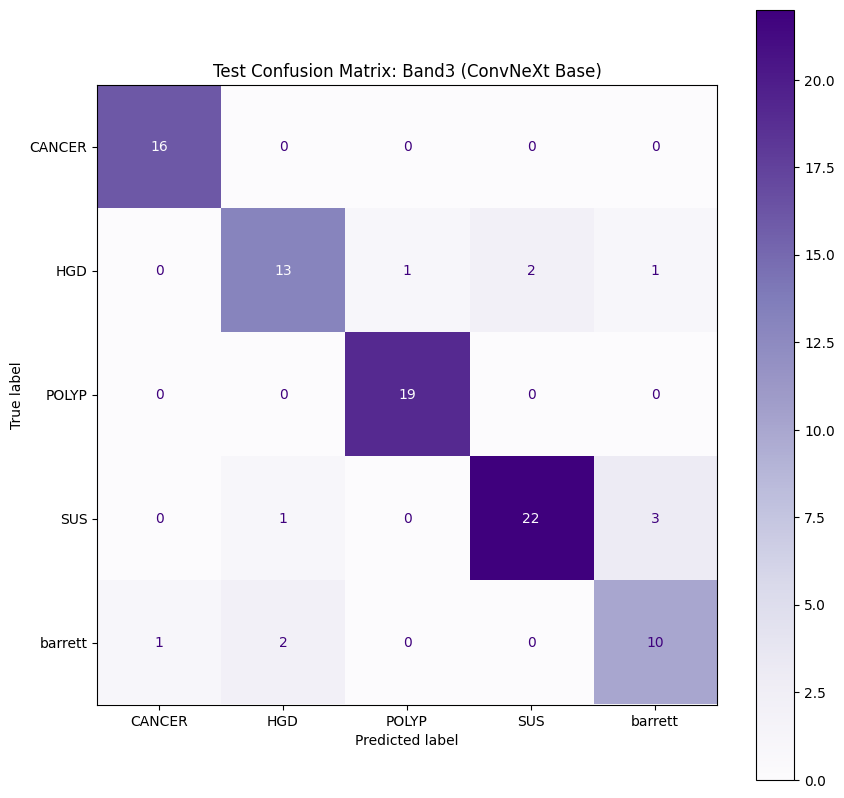

In [ ]:
# ===================== CELL 2: HIGH-ACCURACY CONVNEXT BASE =====================

# 👇 CHANGE THIS VARIABLE TO SWITCH BANDS
BAND_NAME = "Band3"

# Experiment Config
IMG_SIZE = 224
# ⚠️ Batch size reduced to 8 because 'Base' is a large model (avoids Out of Memory)
BATCH_SIZE = 8
NUM_WORKERS = 2
MAX_EPOCHS = 30  # Increased slightly for Cosine Annealing to work its magic
LR = 5e-5        # Lower LR is better for fine-tuning large models
PATIENCE = 5     # Increased patience

# Define Paths
TRAIN_ROOT = f'/content/Team 1/{BAND_NAME}/train'
TEST_ROOT  = f'/content/Team 1/{BAND_NAME}/test'
MODEL_OUT  = f"/content/drive/MyDrive/{BAND_NAME}_convnext_base_best.pth"

print(f"🚀 STARTING HIGH-ACCURACY RUN FOR: {BAND_NAME}")
print(f"🤖 Model Arch: ConvNeXt Base (with TTA & Cosine Annealing)")

# ===================== 1. DATA LOADING & AUGMENTATION =====================
if not os.path.isdir(TRAIN_ROOT) or not os.path.isdir(TEST_ROOT):
    raise RuntimeError(f"❌ Paths not found for {BAND_NAME}.")

# 💪 Stronger Augmentations for Better Generalization
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    # Affine adds Scaling and Shearing (Critical for medical shapes)
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.8, 1.2), shear=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    # Random Blur prevents overfitting to sharp noise
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

full_ds_train = datasets.ImageFolder(TRAIN_ROOT, transform=train_transform)
full_ds_val   = datasets.ImageFolder(TRAIN_ROOT, transform=val_transform)
class_names = full_ds_train.classes
num_classes = len(class_names)

# Split 90/10
train_size = int(0.90 * len(full_ds_train))
val_size = len(full_ds_train) - train_size
g = torch.Generator().manual_seed(42)
train_dataset, _ = random_split(full_ds_train, [train_size, val_size], generator=g)
_, val_dataset   = random_split(full_ds_val,   [train_size, val_size], generator=g)

# Test Set
test_dataset = datasets.ImageFolder(TEST_ROOT, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# ===================== 2. CLASS WEIGHTS =====================
train_labels = [label for _, label in train_dataset]
counts = Counter(train_labels)
class_weights = torch.tensor([1.0 / (counts[i] + 1e-6) for i in range(num_classes)], dtype=torch.float32)
class_weights = class_weights / class_weights.sum() * num_classes
class_weights = class_weights.to(DEVICE)

# ===================== 3. BUILD CONVNEXT BASE =====================
def build_convnext_base(num_classes):
    # 'Base' is significantly smarter than 'Tiny' or 'Small'
    weights = models.ConvNeXt_Base_Weights.DEFAULT
    model = models.convnext_base(weights=weights)

    # Replace Head
    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Linear(in_features, num_classes)
    return model

model = build_convnext_base(num_classes).to(DEVICE)
criterion = FocalLoss(alpha=class_weights, gamma=2.0)

# Optimizer: AdamW with weight decay helps regularization
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.05)

# 🔄 Scheduler: Cosine Annealing with Warm Restarts (Better than Plateau)
# T_0=10 means it restarts the LR every 10 epochs
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=1, eta_min=1e-6)

# ===================== 4. TRAINING LOOP =====================
best_val_loss = float("inf")
epochs_no_improve = 0

print("\n🔄 Phase 1: Training (ConvNeXt Base)...")
for epoch in range(MAX_EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{MAX_EPOCHS}"):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()

        # Gradient Clipping (Prevents exploding gradients in large models)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)

        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100.0 * correct_train / total_train

    # Validation
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    val_loss = val_loss / len(val_loader.dataset)
    val_acc = 100.0 * correct_val / total_val

    # Step Scheduler (Cosine requires step every epoch)
    scheduler.step()

    current_lr = optimizer.param_groups[0]["lr"]
    print(f"   LR: {current_lr:.7f} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), MODEL_OUT)
        print(f"✅ Saved Best Model ({BAND_NAME})")
    else:
        epochs_no_improve += 1
        print(f"⚠️ No improvement: {epochs_no_improve}/{PATIENCE}")

    if epochs_no_improve >= PATIENCE:
        print("🛑 Early stopping triggered.")
        break

# ===================== 5. TEST EVALUATION (WITH TTA) =====================
print(f"\n🔄 Phase 2: Testing with TTA (Test Time Augmentation)...")

model.load_state_dict(torch.load(MODEL_OUT, map_location=DEVICE))
model.eval()

y_test_true = []
y_test_pred = []

# TTA Logic: Predict on image, then predict on Horizontal Flip, then Average
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Testing"):
        imgs = imgs.to(DEVICE)

        # 1. Original Prediction
        outputs1 = model(imgs)

        # 2. Flipped Prediction (Horizontal Flip)
        imgs_flipped = torch.flip(imgs, dims=[3])
        outputs2 = model(imgs_flipped)

        # 3. Average Probabilities (Soft Voting)
        outputs_avg = (outputs1 + outputs2) / 2.0

        preds = torch.argmax(outputs_avg, dim=1).cpu().numpy()
        y_test_pred.extend(preds)
        y_test_true.extend(labels.numpy())

print(f"\n📝 FINAL RESULTS FOR {BAND_NAME} (ConvNeXt Base + TTA):")
print(classification_report(y_test_true, y_test_pred, target_names=class_names))

cm = confusion_matrix(y_test_true, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(10, 10))
disp.plot(cmap="Purples", values_format='d', ax=plt.gca())
plt.title(f"Test Confusion Matrix: {BAND_NAME} (ConvNeXt Base)")
plt.show()

Band23 - 82%

🚀 STARTING EXPERIMENT FOR: Band23
📂 Train Data: /content/Team 1/Band23/train
📂 Test Data:  /content/Team 1/Band23/test
🤖 Model Arch: ConvNeXt (Tiny)
✅ Class Weights Calculated

🔄 Phase 1: Training...


Epoch 1/35: 100%|██████████| 62/62 [00:19<00:00,  3.12it/s]


   Train Loss: 0.6221 | Acc: 48.73%
   Val Loss:   0.3830 | Acc: 64.55%
✅ Saved Best Model (Band23)


Epoch 2/35: 100%|██████████| 62/62 [00:20<00:00,  3.05it/s]


   Train Loss: 0.2348 | Acc: 71.07%
   Val Loss:   0.1302 | Acc: 81.82%
✅ Saved Best Model (Band23)


...

   Train Loss: 0.0252 | Acc: 87.41%
   Val Loss:   0.0238 | Acc: 87.27%
⚠️ No improvement: 4/5


Epoch 13/35: 100%|██████████| 62/62 [00:19<00:00,  3.18it/s]


   Train Loss: 0.0204 | Acc: 88.93%
   Val Loss:   0.0269 | Acc: 84.55%
⚠️ No improvement: 5/5
🛑 Early stopping triggered.

🔄 Phase 2: Testing Best Model on Band23 Test Set...


Testing: 100%|██████████| 6/6 [00:00<00:00,  8.06it/s]



📝 FINAL TEST RESULTS FOR Band23 (ConvNeXt Tiny):
              precision    recall  f1-score   support

      CANCER       0.93      0.81      0.87        16
         HGD       0.87      0.76      0.81        17
       POLYP       0.90      1.00      0.95        19
         SUS       0.90      0.73      0.81        26
     barrett       0.55      0.85      0.67        13

    accuracy                           0.82        91
   macro avg       0.83      0.83      0.82        91
weighted avg       0.85      0.82      0.83        91



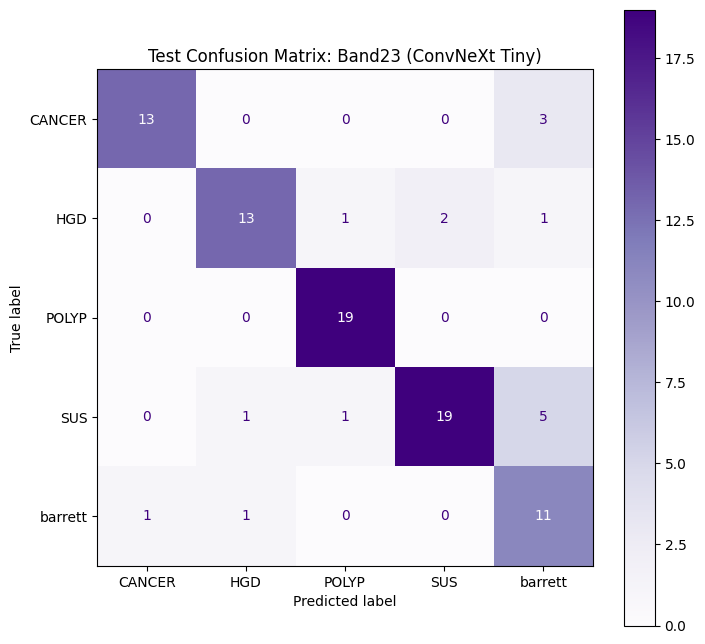

In [ ]:
# ===================== CELL 2: CONVNEXT EXPERIMENT (TRAIN + TEST) =====================

# 👇 CHANGE THIS VARIABLE TO SWITCH BANDS
BAND_NAME = "Band23"

# Experiment Config
# ConvNeXt uses 224x224 standard
IMG_SIZE = 224
BATCH_SIZE = 16 # Adjust to 8 if you run out of GPU memory
NUM_WORKERS = 2
MAX_EPOCHS = 35
LR = 1e-4 # ConvNeXt likes slightly lower LRs, but 1e-4 is a good safe start
PATIENCE = 5

# Define Paths
TRAIN_ROOT = f'/content/Team 1/{BAND_NAME}/train'
TEST_ROOT  = f'/content/Team 1/{BAND_NAME}/test'
MODEL_OUT  = f"/content/drive/MyDrive/{BAND_NAME}_convnext_best.pth"

print(f"🚀 STARTING EXPERIMENT FOR: {BAND_NAME}")
print(f"📂 Train Data: {TRAIN_ROOT}")
print(f"📂 Test Data:  {TEST_ROOT}")
print(f"🤖 Model Arch: ConvNeXt (Tiny)")

# ===================== 1. DATA LOADING =====================
if not os.path.isdir(TRAIN_ROOT) or not os.path.isdir(TEST_ROOT):
    raise RuntimeError(f"❌ Paths not found for {BAND_NAME}. Check directory structure.")

# Modern transforms often help ConvNeXt
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(), # Medical images are often rotation invariant
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Train & Val Sets
full_ds_train = datasets.ImageFolder(TRAIN_ROOT, transform=train_transform)
full_ds_val   = datasets.ImageFolder(TRAIN_ROOT, transform=val_transform)
class_names = full_ds_train.classes
num_classes = len(class_names)

# Split 90/10
train_size = int(0.90 * len(full_ds_train))
val_size = len(full_ds_train) - train_size
g = torch.Generator().manual_seed(42)
train_dataset, _ = random_split(full_ds_train, [train_size, val_size], generator=g)
_, val_dataset   = random_split(full_ds_val,   [train_size, val_size], generator=g)

# Test Set
test_dataset = datasets.ImageFolder(TEST_ROOT, transform=val_transform)

# Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# ===================== 2. CLASS WEIGHTS =====================
train_labels = [label for _, label in train_dataset]
counts = Counter(train_labels)
class_weights = torch.tensor([1.0 / (counts[i] + 1e-6) for i in range(num_classes)], dtype=torch.float32)
class_weights = class_weights / class_weights.sum() * num_classes
class_weights = class_weights.to(DEVICE)
print("✅ Class Weights Calculated")

# ===================== 3. BUILD CONVNEXT MODEL =====================
def build_convnext(num_classes):
    # Load Pre-trained ConvNeXt Tiny (Weights are IMAGENET1K_V1)
    weights = models.ConvNeXt_Tiny_Weights.DEFAULT
    model = models.convnext_tiny(weights=weights)

    # ConvNeXt classifier structure:
    # (2): Linear(in_features=768, out_features=1000, bias=True)
    # We replace the last layer (index 2 in the classifier sequential block)
    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Linear(in_features, num_classes)
    return model

model = build_convnext(num_classes).to(DEVICE)
criterion = FocalLoss(alpha=class_weights, gamma=2.0)
# ConvNeXt often benefits from AdamW with slightly different betas, but defaults are usually fine
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

# ===================== 4. TRAINING LOOP =====================
best_val_loss = float("inf")
epochs_no_improve = 0
prev_lr = LR

print("\n🔄 Phase 1: Training...")
for epoch in range(MAX_EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{MAX_EPOCHS}"):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100.0 * correct_train / total_train

    # Validation
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    val_loss = val_loss / len(val_loader.dataset)
    val_acc = 100.0 * correct_val / total_val

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]
    if current_lr != prev_lr:
        print(f"ℹ️ LR reduced: {prev_lr:.6f} → {current_lr:.6f}")
        prev_lr = current_lr

    print(f"   Train Loss: {train_loss:.4f} | Acc: {train_acc:.2f}%")
    print(f"   Val Loss:   {val_loss:.4f} | Acc: {val_acc:.2f}%")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), MODEL_OUT)
        print(f"✅ Saved Best Model ({BAND_NAME})")
    else:
        epochs_no_improve += 1
        print(f"⚠️ No improvement: {epochs_no_improve}/{PATIENCE}")

    if epochs_no_improve >= PATIENCE:
        print("🛑 Early stopping triggered.")
        break

# ===================== 5. TEST EVALUATION =====================
print(f"\n🔄 Phase 2: Testing Best Model on {BAND_NAME} Test Set...")

# Load the best model we just saved
model.load_state_dict(torch.load(MODEL_OUT, map_location=DEVICE))
model.eval()

y_test_true = []
y_test_pred = []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Testing"):
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        y_test_pred.extend(preds)
        y_test_true.extend(labels.numpy())

print(f"\n📝 FINAL TEST RESULTS FOR {BAND_NAME} (ConvNeXt Tiny):")
print(classification_report(y_test_true, y_test_pred, target_names=class_names))

cm = confusion_matrix(y_test_true, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(8, 8))
disp.plot(cmap="Purples", values_format='d', ax=plt.gca())
plt.title(f"Test Confusion Matrix: {BAND_NAME} (ConvNeXt Tiny)")
plt.show()

Band 123 - 89%

🚀 STARTING EXPERIMENT FOR: Band123
📂 Train Data: /content/Team 1/Band123/train
📂 Test Data:  /content/Team 1/Band123/test
🤖 Model Arch: ConvNeXt (Tiny)
✅ Class Weights Calculated

🔄 Phase 1: Training...


Epoch 1/50: 100%|██████████| 62/62 [00:20<00:00,  3.06it/s]


   Train Loss: 0.5519 | Acc: 53.10%
   Val Loss:   0.2782 | Acc: 68.18%
✅ Saved Best Model (Band123)


Epoch 2/50: 100%|██████████| 62/62 [00:20<00:00,  3.01it/s]


   Train Loss: 0.1712 | Acc: 75.23%
   Val Loss:   0.1187 | Acc: 79.09%
✅ Saved Best Model (Band123)


...

ℹ️ LR reduced: 0.000025 → 0.000013
   Train Loss: 0.0120 | Acc: 90.56%
   Val Loss:   0.0139 | Acc: 93.64%
⚠️ No improvement: 6/7


Epoch 27/50: 100%|██████████| 62/62 [00:19<00:00,  3.18it/s]


   Train Loss: 0.0093 | Acc: 93.20%
   Val Loss:   0.0138 | Acc: 91.82%
⚠️ No improvement: 7/7
🛑 Early stopping triggered.

🔄 Phase 2: Testing Best Model on Band123 Test Set...


Testing: 100%|██████████| 6/6 [00:00<00:00,  7.68it/s]



📝 FINAL TEST RESULTS FOR Band123 (ConvNeXt Tiny):
              precision    recall  f1-score   support

      CANCER       0.94      1.00      0.97        16
         HGD       0.88      0.82      0.85        17
       POLYP       0.95      1.00      0.97        19
         SUS       0.91      0.81      0.86        26
     barrett       0.73      0.85      0.79        13

    accuracy                           0.89        91
   macro avg       0.88      0.90      0.89        91
weighted avg       0.89      0.89      0.89        91



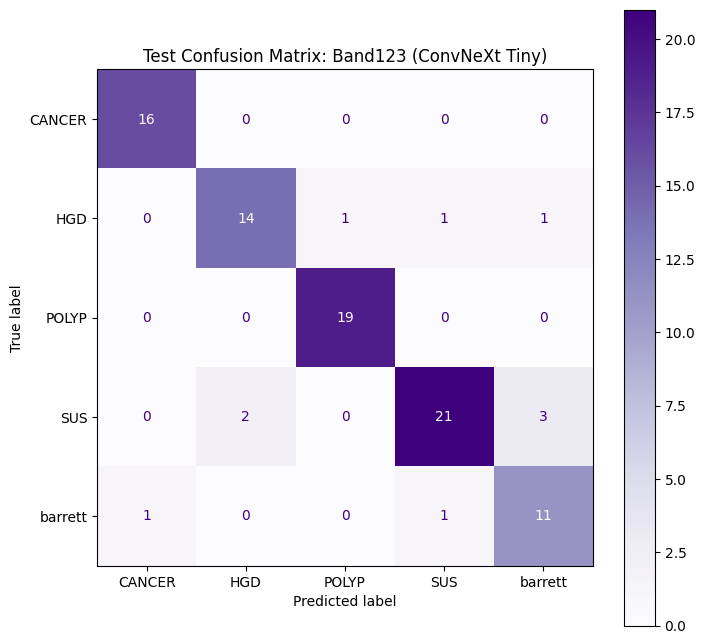

In [ ]:
# ===================== CELL 2: CONVNEXT EXPERIMENT (TRAIN + TEST) =====================

# 👇 CHANGE THIS VARIABLE TO SWITCH BANDS
BAND_NAME = "Band123"

# Experiment Config
# ConvNeXt uses 224x224 standard
IMG_SIZE = 224
BATCH_SIZE = 16 # Adjust to 8 if you run out of GPU memory
NUM_WORKERS = 2
MAX_EPOCHS = 50
LR = 1e-4 # ConvNeXt likes slightly lower LRs, but 1e-4 is a good safe start
PATIENCE = 7

# Define Paths
TRAIN_ROOT = f'/content/Team 1/{BAND_NAME}/train'
TEST_ROOT  = f'/content/Team 1/{BAND_NAME}/test'
MODEL_OUT  = f"/content/drive/MyDrive/{BAND_NAME}_convnext_best.pth"

print(f"🚀 STARTING EXPERIMENT FOR: {BAND_NAME}")
print(f"📂 Train Data: {TRAIN_ROOT}")
print(f"📂 Test Data:  {TEST_ROOT}")
print(f"🤖 Model Arch: ConvNeXt (Tiny)")

# ===================== 1. DATA LOADING =====================
if not os.path.isdir(TRAIN_ROOT) or not os.path.isdir(TEST_ROOT):
    raise RuntimeError(f"❌ Paths not found for {BAND_NAME}. Check directory structure.")

# Modern transforms often help ConvNeXt
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(), # Medical images are often rotation invariant
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Train & Val Sets
full_ds_train = datasets.ImageFolder(TRAIN_ROOT, transform=train_transform)
full_ds_val   = datasets.ImageFolder(TRAIN_ROOT, transform=val_transform)
class_names = full_ds_train.classes
num_classes = len(class_names)

# Split 90/10
train_size = int(0.90 * len(full_ds_train))
val_size = len(full_ds_train) - train_size
g = torch.Generator().manual_seed(42)
train_dataset, _ = random_split(full_ds_train, [train_size, val_size], generator=g)
_, val_dataset   = random_split(full_ds_val,   [train_size, val_size], generator=g)

# Test Set
test_dataset = datasets.ImageFolder(TEST_ROOT, transform=val_transform)

# Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# ===================== 2. CLASS WEIGHTS =====================
train_labels = [label for _, label in train_dataset]
counts = Counter(train_labels)
class_weights = torch.tensor([1.0 / (counts[i] + 1e-6) for i in range(num_classes)], dtype=torch.float32)
class_weights = class_weights / class_weights.sum() * num_classes
class_weights = class_weights.to(DEVICE)
print("✅ Class Weights Calculated")

# ===================== 3. BUILD CONVNEXT MODEL =====================
def build_convnext(num_classes):
    # Load Pre-trained ConvNeXt Tiny (Weights are IMAGENET1K_V1)
    weights = models.ConvNeXt_Tiny_Weights.DEFAULT
    model = models.convnext_tiny(weights=weights)

    # ConvNeXt classifier structure:
    # (2): Linear(in_features=768, out_features=1000, bias=True)
    # We replace the last layer (index 2 in the classifier sequential block)
    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Linear(in_features, num_classes)
    return model

model = build_convnext(num_classes).to(DEVICE)
criterion = FocalLoss(alpha=class_weights, gamma=2.0)
# ConvNeXt often benefits from AdamW with slightly different betas, but defaults are usually fine
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

# ===================== 4. TRAINING LOOP =====================
best_val_loss = float("inf")
epochs_no_improve = 0
prev_lr = LR

print("\n🔄 Phase 1: Training...")
for epoch in range(MAX_EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{MAX_EPOCHS}"):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100.0 * correct_train / total_train

    # Validation
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    val_loss = val_loss / len(val_loader.dataset)
    val_acc = 100.0 * correct_val / total_val

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]
    if current_lr != prev_lr:
        print(f"ℹ️ LR reduced: {prev_lr:.6f} → {current_lr:.6f}")
        prev_lr = current_lr

    print(f"   Train Loss: {train_loss:.4f} | Acc: {train_acc:.2f}%")
    print(f"   Val Loss:   {val_loss:.4f} | Acc: {val_acc:.2f}%")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), MODEL_OUT)
        print(f"✅ Saved Best Model ({BAND_NAME})")
    else:
        epochs_no_improve += 1
        print(f"⚠️ No improvement: {epochs_no_improve}/{PATIENCE}")

    if epochs_no_improve >= PATIENCE:
        print("🛑 Early stopping triggered.")
        break

# ===================== 5. TEST EVALUATION =====================
print(f"\n🔄 Phase 2: Testing Best Model on {BAND_NAME} Test Set...")

# Load the best model we just saved
model.load_state_dict(torch.load(MODEL_OUT, map_location=DEVICE))
model.eval()

y_test_true = []
y_test_pred = []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Testing"):
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        y_test_pred.extend(preds)
        y_test_true.extend(labels.numpy())

print(f"\n📝 FINAL TEST RESULTS FOR {BAND_NAME} (ConvNeXt Tiny):")
print(classification_report(y_test_true, y_test_pred, target_names=class_names))

cm = confusion_matrix(y_test_true, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(8, 8))
disp.plot(cmap="Purples", values_format='d', ax=plt.gca())
plt.title(f"Test Confusion Matrix: {BAND_NAME} (ConvNeXt Tiny)")
plt.show()

Band2 - 88%

🚀 STARTING EXPERIMENT FOR: Band2
📂 Train Data: /content/Team 1/Band2/train
📂 Test Data:  /content/Team 1/Band2/test
🤖 Model Arch: ConvNeXt (Tiny)
✅ Class Weights Calculated

🔄 Phase 1: Training...


Epoch 1/30: 100%|██████████| 62/62 [00:19<00:00,  3.10it/s]


   Train Loss: 0.7471 | Acc: 42.13%
   Val Loss:   0.4676 | Acc: 55.45%
✅ Saved Best Model (Band2)


Epoch 2/30: 100%|██████████| 62/62 [00:20<00:00,  3.08it/s]


   Train Loss: 0.3474 | Acc: 60.51%
   Val Loss:   0.2814 | Acc: 67.27%
✅ Saved Best Model (Band2)


...

   Train Loss: 0.0480 | Acc: 84.06%
   Val Loss:   0.0391 | Acc: 85.45%
⚠️ No improvement: 2/3


Epoch 11/30: 100%|██████████| 62/62 [00:19<00:00,  3.15it/s]


ℹ️ LR reduced: 0.000100 → 0.000050
   Train Loss: 0.0352 | Acc: 85.69%
   Val Loss:   0.0319 | Acc: 90.91%
⚠️ No improvement: 3/3
🛑 Early stopping triggered.

🔄 Phase 2: Testing Best Model on Band2 Test Set...


Testing: 100%|██████████| 6/6 [00:00<00:00,  8.12it/s]



📝 FINAL TEST RESULTS FOR Band2 (ConvNeXt Tiny):
              precision    recall  f1-score   support

      CANCER       0.94      1.00      0.97        16
         HGD       0.93      0.76      0.84        17
       POLYP       1.00      1.00      1.00        19
         SUS       0.88      0.81      0.84        26
     barrett       0.65      0.85      0.73        13

    accuracy                           0.88        91
   macro avg       0.88      0.88      0.88        91
weighted avg       0.89      0.88      0.88        91



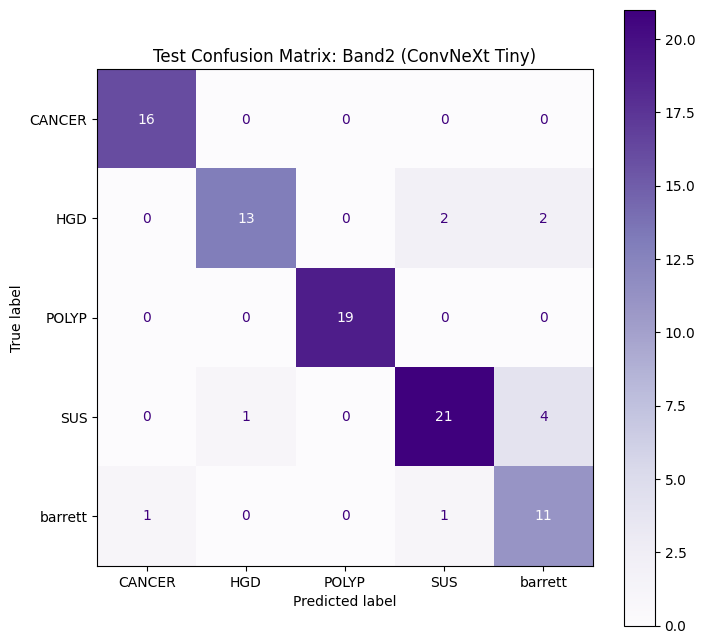

In [ ]:
# ===================== CELL 2: CONVNEXT EXPERIMENT (TRAIN + TEST) =====================

# 👇 CHANGE THIS VARIABLE TO SWITCH BANDS
BAND_NAME = "Band2"

# Experiment Config
# ConvNeXt uses 224x224 standard
IMG_SIZE = 224
BATCH_SIZE = 16 # Adjust to 8 if you run out of GPU memory
NUM_WORKERS = 2
MAX_EPOCHS = 30
LR = 1e-4 # ConvNeXt likes slightly lower LRs, but 1e-4 is a good safe start
PATIENCE = 3

# Define Paths
TRAIN_ROOT = f'/content/Team 1/{BAND_NAME}/train'
TEST_ROOT  = f'/content/Team 1/{BAND_NAME}/test'
MODEL_OUT  = f"/content/drive/MyDrive/{BAND_NAME}_convnext_best.pth"

print(f"🚀 STARTING EXPERIMENT FOR: {BAND_NAME}")
print(f"📂 Train Data: {TRAIN_ROOT}")
print(f"📂 Test Data:  {TEST_ROOT}")
print(f"🤖 Model Arch: ConvNeXt (Tiny)")

# ===================== 1. DATA LOADING =====================
if not os.path.isdir(TRAIN_ROOT) or not os.path.isdir(TEST_ROOT):
    raise RuntimeError(f"❌ Paths not found for {BAND_NAME}. Check directory structure.")

# Modern transforms often help ConvNeXt
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(), # Medical images are often rotation invariant
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Train & Val Sets
full_ds_train = datasets.ImageFolder(TRAIN_ROOT, transform=train_transform)
full_ds_val   = datasets.ImageFolder(TRAIN_ROOT, transform=val_transform)
class_names = full_ds_train.classes
num_classes = len(class_names)

# Split 90/10
train_size = int(0.90 * len(full_ds_train))
val_size = len(full_ds_train) - train_size
g = torch.Generator().manual_seed(42)
train_dataset, _ = random_split(full_ds_train, [train_size, val_size], generator=g)
_, val_dataset   = random_split(full_ds_val,   [train_size, val_size], generator=g)

# Test Set
test_dataset = datasets.ImageFolder(TEST_ROOT, transform=val_transform)

# Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# ===================== 2. CLASS WEIGHTS =====================
train_labels = [label for _, label in train_dataset]
counts = Counter(train_labels)
class_weights = torch.tensor([1.0 / (counts[i] + 1e-6) for i in range(num_classes)], dtype=torch.float32)
class_weights = class_weights / class_weights.sum() * num_classes
class_weights = class_weights.to(DEVICE)
print("✅ Class Weights Calculated")

# ===================== 3. BUILD CONVNEXT MODEL =====================
def build_convnext(num_classes):
    # Load Pre-trained ConvNeXt Tiny (Weights are IMAGENET1K_V1)
    weights = models.ConvNeXt_Tiny_Weights.DEFAULT
    model = models.convnext_tiny(weights=weights)

    # ConvNeXt classifier structure:
    # (2): Linear(in_features=768, out_features=1000, bias=True)
    # We replace the last layer (index 2 in the classifier sequential block)
    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Linear(in_features, num_classes)
    return model

model = build_convnext(num_classes).to(DEVICE)
criterion = FocalLoss(alpha=class_weights, gamma=2.0)
# ConvNeXt often benefits from AdamW with slightly different betas, but defaults are usually fine
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

# ===================== 4. TRAINING LOOP =====================
best_val_loss = float("inf")
epochs_no_improve = 0
prev_lr = LR

print("\n🔄 Phase 1: Training...")
for epoch in range(MAX_EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{MAX_EPOCHS}"):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100.0 * correct_train / total_train

    # Validation
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    val_loss = val_loss / len(val_loader.dataset)
    val_acc = 100.0 * correct_val / total_val

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]
    if current_lr != prev_lr:
        print(f"ℹ️ LR reduced: {prev_lr:.6f} → {current_lr:.6f}")
        prev_lr = current_lr

    print(f"   Train Loss: {train_loss:.4f} | Acc: {train_acc:.2f}%")
    print(f"   Val Loss:   {val_loss:.4f} | Acc: {val_acc:.2f}%")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), MODEL_OUT)
        print(f"✅ Saved Best Model ({BAND_NAME})")
    else:
        epochs_no_improve += 1
        print(f"⚠️ No improvement: {epochs_no_improve}/{PATIENCE}")

    if epochs_no_improve >= PATIENCE:
        print("🛑 Early stopping triggered.")
        break

# ===================== 5. TEST EVALUATION =====================
print(f"\n🔄 Phase 2: Testing Best Model on {BAND_NAME} Test Set...")

# Load the best model we just saved
model.load_state_dict(torch.load(MODEL_OUT, map_location=DEVICE))
model.eval()

y_test_true = []
y_test_pred = []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Testing"):
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        y_test_pred.extend(preds)
        y_test_true.extend(labels.numpy())

print(f"\n📝 FINAL TEST RESULTS FOR {BAND_NAME} (ConvNeXt Tiny):")
print(classification_report(y_test_true, y_test_pred, target_names=class_names))

cm = confusion_matrix(y_test_true, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(8, 8))
disp.plot(cmap="Purples", values_format='d', ax=plt.gca())
plt.title(f"Test Confusion Matrix: {BAND_NAME} (ConvNeXt Tiny)")
plt.show()

WLI - 74%

🚀 STARTING EXPERIMENT FOR: WLI
📂 Train Data: /content/Team 1/WLI/train
📂 Test Data:  /content/Team 1/WLI/test
🤖 Model Arch: ConvNeXt (Tiny)
✅ Class Weights Calculated

🔄 Phase 1: Training...


Epoch 1/30: 100%|██████████| 62/62 [00:20<00:00,  3.05it/s]


   Train Loss: 0.5175 | Acc: 56.75%
   Val Loss:   0.1869 | Acc: 80.00%
✅ Saved Best Model (WLI)


Epoch 2/30: 100%|██████████| 62/62 [00:20<00:00,  3.09it/s]


   Train Loss: 0.1426 | Acc: 76.75%
   Val Loss:   0.1033 | Acc: 80.00%
✅ Saved Best Model (WLI)


...

   Train Loss: 0.0208 | Acc: 88.63%
   Val Loss:   0.0284 | Acc: 88.18%
⚠️ No improvement: 2/3


Epoch 15/30: 100%|██████████| 62/62 [00:19<00:00,  3.15it/s]


ℹ️ LR reduced: 0.000100 → 0.000050
   Train Loss: 0.0188 | Acc: 89.14%
   Val Loss:   0.0364 | Acc: 90.00%
⚠️ No improvement: 3/3
🛑 Early stopping triggered.

🔄 Phase 2: Testing Best Model on WLI Test Set...


Testing: 100%|██████████| 9/9 [00:01<00:00,  6.09it/s]



📝 FINAL TEST RESULTS FOR WLI (ConvNeXt Tiny):
              precision    recall  f1-score   support

      CANCER       0.91      0.77      0.83        26
         HGD       0.75      0.67      0.71        27
       POLYP       0.91      0.97      0.94        31
         SUS       0.77      0.67      0.72        36
     barrett       0.41      0.58      0.48        24

    accuracy                           0.74       144
   macro avg       0.75      0.73      0.74       144
weighted avg       0.76      0.74      0.74       144



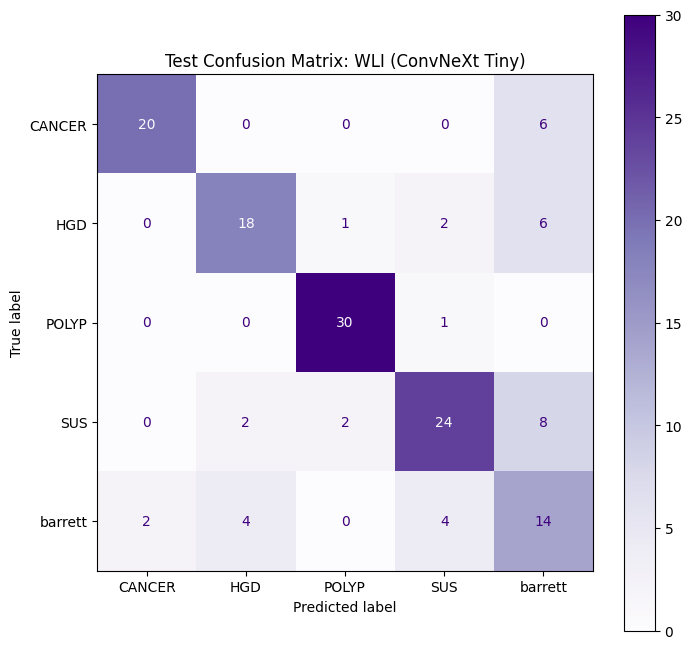

In [ ]:
# ===================== CELL 2: CONVNEXT EXPERIMENT (TRAIN + TEST) =====================

# 👇 CHANGE THIS VARIABLE TO SWITCH BANDS
BAND_NAME = "WLI"

# Experiment Config
# ConvNeXt uses 224x224 standard
IMG_SIZE = 224
BATCH_SIZE = 16 # Adjust to 8 if you run out of GPU memory
NUM_WORKERS = 2
MAX_EPOCHS = 30
LR = 1e-4 # ConvNeXt likes slightly lower LRs, but 1e-4 is a good safe start
PATIENCE = 3

# Define Paths
TRAIN_ROOT = f'/content/Team 1/{BAND_NAME}/train'
TEST_ROOT  = f'/content/Team 1/{BAND_NAME}/test'
MODEL_OUT  = f"/content/drive/MyDrive/{BAND_NAME}_convnext_best.pth"

print(f"🚀 STARTING EXPERIMENT FOR: {BAND_NAME}")
print(f"📂 Train Data: {TRAIN_ROOT}")
print(f"📂 Test Data:  {TEST_ROOT}")
print(f"🤖 Model Arch: ConvNeXt (Tiny)")

# ===================== 1. DATA LOADING =====================
if not os.path.isdir(TRAIN_ROOT) or not os.path.isdir(TEST_ROOT):
    raise RuntimeError(f"❌ Paths not found for {BAND_NAME}. Check directory structure.")

# Modern transforms often help ConvNeXt
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(), # Medical images are often rotation invariant
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Train & Val Sets
full_ds_train = datasets.ImageFolder(TRAIN_ROOT, transform=train_transform)
full_ds_val   = datasets.ImageFolder(TRAIN_ROOT, transform=val_transform)
class_names = full_ds_train.classes
num_classes = len(class_names)

# Split 90/10
train_size = int(0.90 * len(full_ds_train))
val_size = len(full_ds_train) - train_size
g = torch.Generator().manual_seed(42)
train_dataset, _ = random_split(full_ds_train, [train_size, val_size], generator=g)
_, val_dataset   = random_split(full_ds_val,   [train_size, val_size], generator=g)

# Test Set
test_dataset = datasets.ImageFolder(TEST_ROOT, transform=val_transform)

# Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# ===================== 2. CLASS WEIGHTS =====================
train_labels = [label for _, label in train_dataset]
counts = Counter(train_labels)
class_weights = torch.tensor([1.0 / (counts[i] + 1e-6) for i in range(num_classes)], dtype=torch.float32)
class_weights = class_weights / class_weights.sum() * num_classes
class_weights = class_weights.to(DEVICE)
print("✅ Class Weights Calculated")

# ===================== 3. BUILD CONVNEXT MODEL =====================
def build_convnext(num_classes):
    # Load Pre-trained ConvNeXt Tiny (Weights are IMAGENET1K_V1)
    weights = models.ConvNeXt_Tiny_Weights.DEFAULT
    model = models.convnext_tiny(weights=weights)

    # ConvNeXt classifier structure:
    # (2): Linear(in_features=768, out_features=1000, bias=True)
    # We replace the last layer (index 2 in the classifier sequential block)
    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Linear(in_features, num_classes)
    return model

model = build_convnext(num_classes).to(DEVICE)
criterion = FocalLoss(alpha=class_weights, gamma=2.0)
# ConvNeXt often benefits from AdamW with slightly different betas, but defaults are usually fine
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

# ===================== 4. TRAINING LOOP =====================
best_val_loss = float("inf")
epochs_no_improve = 0
prev_lr = LR

print("\n🔄 Phase 1: Training...")
for epoch in range(MAX_EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{MAX_EPOCHS}"):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100.0 * correct_train / total_train

    # Validation
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    val_loss = val_loss / len(val_loader.dataset)
    val_acc = 100.0 * correct_val / total_val

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]
    if current_lr != prev_lr:
        print(f"ℹ️ LR reduced: {prev_lr:.6f} → {current_lr:.6f}")
        prev_lr = current_lr

    print(f"   Train Loss: {train_loss:.4f} | Acc: {train_acc:.2f}%")
    print(f"   Val Loss:   {val_loss:.4f} | Acc: {val_acc:.2f}%")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), MODEL_OUT)
        print(f"✅ Saved Best Model ({BAND_NAME})")
    else:
        epochs_no_improve += 1
        print(f"⚠️ No improvement: {epochs_no_improve}/{PATIENCE}")

    if epochs_no_improve >= PATIENCE:
        print("🛑 Early stopping triggered.")
        break

# ===================== 5. TEST EVALUATION =====================
print(f"\n🔄 Phase 2: Testing Best Model on {BAND_NAME} Test Set...")

# Load the best model we just saved
model.load_state_dict(torch.load(MODEL_OUT, map_location=DEVICE))
model.eval()

y_test_true = []
y_test_pred = []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Testing"):
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        y_test_pred.extend(preds)
        y_test_true.extend(labels.numpy())

print(f"\n📝 FINAL TEST RESULTS FOR {BAND_NAME} (ConvNeXt Tiny):")
print(classification_report(y_test_true, y_test_pred, target_names=class_names))

cm = confusion_matrix(y_test_true, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(8, 8))
disp.plot(cmap="Purples", values_format='d', ax=plt.gca())
plt.title(f"Test Confusion Matrix: {BAND_NAME} (ConvNeXt Tiny)")
plt.show()

# YOLOv8 EXPERIMENT

In [ ]:
# ===================== CELL 1: INSTALL YOLO (Run Once) =====================
!pip install ultralytics -q
import ultralytics
ultralytics.checks()
print("✅ YOLOv8 Installed and Ready!")

Ultralytics 8.4.11 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 40.7/112.6 GB disk)
✅ YOLOv8 Installed and Ready!


Band3 - 89%

🚀 STARTING YOLOv8 EXPERIMENT FOR: Band3
📂 Data Root: /content/Team 1/Band3
ℹ️ Creating 'val' folder from 'test' for YOLO requirements...
✅ 'val' folder created successfully.

🔄 Phase 1: Training...
Ultralytics 8.4.11 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Team 1/Band3, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=t

/usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic 

AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1722.8±631.5 MB/s, size: 38.0 KB)
train: Scanning /content/Team 1/Band3/train... 1095 images, 0 corrupt: 100% ━━━━━━━━━━━━ 1095/1095 5.9Kit/s 0.2s
train: New cache created: /content/Team 1/Band3/train.cache
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 408.0±146.9 MB/s, size: 34.0 KB)
val: Scanning /content/Team 1/Band3/val... 91 images, 0 corrupt: 100% ━━━━━━━━━━━━ 91/91 4.1Kit/s 0.0s
val: New cache created: /content/Team 1/Band3/val.cache
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001111, momentum=0.9) with parameter groups 38 weight(decay=0.0), 39 weight(decay=0.0005), 39 bias(decay=0.0)
Image sizes 224 train, 224 val
Using 2 dataloader workers
Logging results to /content/drive/MyDrive/YOLO_Runs/Band3_yolo
Starting training for 30 epochs...

      Epoch    GPU_mem       loss  Insta

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/30      3.21G      1.673         16        224: 1% ──────────── 1/69 1.0it/s 2.2s<1:08

...

      21/30      3.96G     0.4382          7        224: 100% ━━━━━━━━━━━━ 69/69 6.1it/s 11.3s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 3/3 23.0it/s 0.1s
                   all      0.846          1

      Epoch    GPU_mem       loss  Instances       Size
      22/30      4.05G     0.4321         16        224: 1% ──────────── 1/69 1.7it/s 0.2s<40.4s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      22/30      4.07G     0.4422          7        224: 100% ━━━━━━━━━━━━ 69/69 7.8it/s 8.9s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 3/3 16.5it/s 0.2s
                   all      0.857          1

      Epoch    GPU_mem       loss  Instances       Size
      23/30      4.15G     0.4781         16        224: 1% ──────────── 1/69 1.8it/s 0.3s<37.4s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      23/30      4.16G     0.4117          7        224: 100% ━━━━━━━━━━━━ 69/69 7.6it/s 9.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 3/3 23.9it/s 0.1s
                   all      0.846          1
EarlyStopping: Training stopped early as no improvement observed in last 5 epochs. Best results observed at epoch 18, best model saved as best.pt.
To update EarlyStopping(patience=5) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

23 epochs completed in 0.089 hours.
Optimizer stripped from /content/drive/MyDrive/YOLO_Runs/Band3_yolo/weights/last.pt, 31.7MB
Optimizer stripped from /content/drive/MyDrive/YOLO_Runs/Band3_yolo/weights/best.pt, 31.7MB

Validating /content/drive/MyDrive/YOLO_Runs/Band3_yolo/weights/best.pt...
Ultralytics 8.4.11 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8m-cls summary (fused): 42 layers, 15,769,061 parameters, 0 gradients, 41.6 GFLOPs
train: /content/Team 1/Band3/train...

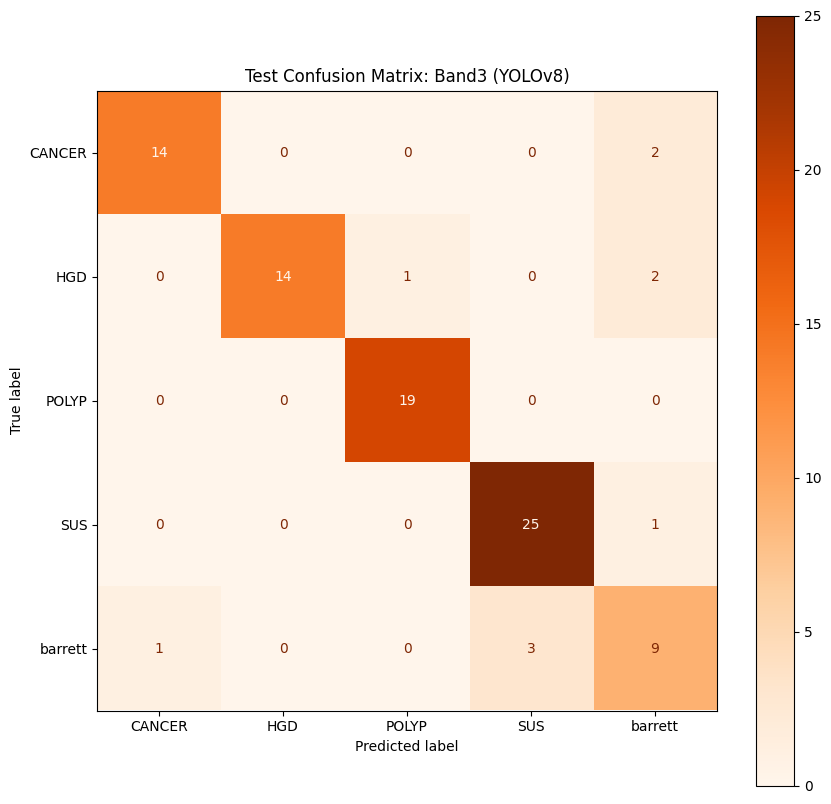

In [ ]:
# ===================== CELL 2: YOLOv8 EXPERIMENT =====================
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from ultralytics import YOLO

# 👇 CHANGE THIS VARIABLE TO SWITCH BANDS
BAND_NAME = "Band3"

# Experiment Config
MODEL_TYPE = "yolov8m-cls.pt"  # Medium model (Balance of speed/accuracy)
MAX_EPOCHS = 30
IMG_SIZE = 224
BATCH_SIZE = 16

# Define Paths
# YOLO is strict about paths. We define the root folder that contains 'train' and 'test'
DATA_ROOT = f'/content/Team 1/{BAND_NAME}'
TRAIN_DIR = f'{DATA_ROOT}/train'
TEST_DIR  = f'{DATA_ROOT}/test'

print(f"🚀 STARTING YOLOv8 EXPERIMENT FOR: {BAND_NAME}")
print(f"📂 Data Root: {DATA_ROOT}")

# ===================== 1. YOLO FOLDER SETUP =====================
# YOLO requires a folder named 'val' to validate during training.
# We will copy your 'test' folder to 'val' so YOLO can use it.
VAL_DIR = f'{DATA_ROOT}/val'

if not os.path.isdir(VAL_DIR):
    print(f"ℹ️ Creating 'val' folder from 'test' for YOLO requirements...")
    # We use copytree to duplicate test data into a val folder
    shutil.copytree(TEST_DIR, VAL_DIR, dirs_exist_ok=True)
    print("✅ 'val' folder created successfully.")
else:
    print("✅ 'val' folder already exists.")

# ===================== 2. TRAINING LOOP =====================
# Load Pretrained Model
model = YOLO(MODEL_TYPE)

print("\n🔄 Phase 1: Training...")
# YOLO handles the training loop internally
results = model.train(
    data=DATA_ROOT,       # Point to folder containing train/val
    epochs=MAX_EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    patience=5,
    project=f"/content/drive/MyDrive/YOLO_Runs",  # Save to Drive
    name=f"{BAND_NAME}_yolo",
    exist_ok=True,        # Overwrite if exists
    verbose=True
)

print(f"✅ Training Complete. Saved to Drive.")

# ===================== 3. FINAL EVALUATION =====================
print(f"\n🔄 Phase 2: Generating Final Classification Report...")

# Load the best model weights from the run we just finished
best_weight_path = f"/content/drive/MyDrive/YOLO_Runs/{BAND_NAME}_yolo/weights/best.pt"
model = YOLO(best_weight_path)

# Get class names from the folder structure
class_names = sorted([d for d in os.listdir(TEST_DIR) if os.path.isdir(os.path.join(TEST_DIR, d))])
class_map = {name: i for i, name in enumerate(class_names)}

y_true = []
y_pred = []

print("⏳ Running inference on Test set...")

# Iterate through each class folder (Like ImageFolder)
for class_name in class_names:
    class_dir = os.path.join(TEST_DIR, class_name)
    image_files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    for img_file in image_files:
        img_path = os.path.join(class_dir, img_file)

        # Run Inference
        result = model(img_path, verbose=False)[0]

        # Store Truth
        y_true.append(class_map[class_name])

        # Store Prediction (Top-1 class index)
        y_pred.append(result.probs.top1)

# ===================== 4. DISPLAY RESULTS =====================
print(f"\n📝 FINAL TEST RESULTS FOR {BAND_NAME} (YOLOv8):")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(10, 10))
disp.plot(cmap="Oranges", values_format='d', ax=plt.gca())
plt.title(f"Test Confusion Matrix: {BAND_NAME} (YOLOv8)")
plt.show()

Band123 - 89%

🚀 STARTING YOLOv8 EXPERIMENT FOR: Band123
📂 Data Root: /content/Team 1/Band123
ℹ️ Creating 'val' folder from 'test' for YOLO requirements...
✅ 'val' folder created successfully.

🔄 Phase 1: Training...
Ultralytics 8.4.11 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Team 1/Band123, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, 

/usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic 

AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 211.8±250.1 MB/s, size: 69.6 KB)
train: Scanning /content/Team 1/Band123/train... 1095 images, 0 corrupt: 100% ━━━━━━━━━━━━ 1095/1095 523.2it/s 2.1s
train: New cache created: /content/Team 1/Band123/train.cache
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 326.0±187.0 MB/s, size: 68.8 KB)
val: Scanning /content/Team 1/Band123/val... 91 images, 0 corrupt: 100% ━━━━━━━━━━━━ 91/91 2.2Kit/s 0.0s
val: New cache created: /content/Team 1/Band123/val.cache
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001111, momentum=0.9) with parameter groups 38 weight(decay=0.0), 39 weight(decay=0.0005), 39 bias(decay=0.0)
Image sizes 224 train, 224 val
Using 2 dataloader workers
Logging results to /content/drive/MyDrive/YOLO_Runs/Band123_yolo
Starting training for 30 epochs...

      Epoch    GPU_mem       l

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/30      2.67G      1.482          7        224: 100% ━━━━━━━━━━━━ 69/69 5.1it/s 13.4s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 3/3 20.6it/s 0.1s
                   all      0.593          1

      Epoch    GPU_mem       loss  Instances       Size
       2/30      2.76G      1.232         16        224: 1% ──────────── 1/69 1.6it/s 0.2s<43.6s

...

      17/30      3.98G      0.343          7        224: 100% ━━━━━━━━━━━━ 69/69 7.0it/s 9.8s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 3/3 17.3it/s 0.2s
                   all      0.868          1

      Epoch    GPU_mem       loss  Instances       Size
      18/30      4.05G     0.1556         16        224: 0% ──────────── 0/69  0.1s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      18/30      4.09G      0.322          7        224: 100% ━━━━━━━━━━━━ 69/69 6.0it/s 11.4s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 3/3 16.4it/s 0.2s
                   all      0.879          1

      Epoch    GPU_mem       loss  Instances       Size
      19/30      4.15G     0.3404         16        224: 1% ──────────── 1/69 1.6it/s 0.3s<43.6s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      19/30      4.17G     0.2912          7        224: 100% ━━━━━━━━━━━━ 69/69 6.5it/s 10.6s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 3/3 21.9it/s 0.1s
                   all      0.868          1
EarlyStopping: Training stopped early as no improvement observed in last 5 epochs. Best results observed at epoch 14, best model saved as best.pt.
To update EarlyStopping(patience=5) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

19 epochs completed in 0.071 hours.
Optimizer stripped from /content/drive/MyDrive/YOLO_Runs/Band123_yolo/weights/last.pt, 31.7MB
Optimizer stripped from /content/drive/MyDrive/YOLO_Runs/Band123_yolo/weights/best.pt, 31.7MB

Validating /content/drive/MyDrive/YOLO_Runs/Band123_yolo/weights/best.pt...
Ultralytics 8.4.11 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8m-cls summary (fused): 42 layers, 15,769,061 parameters, 0 gradients, 41.6 GFLOPs
train: /content/Team 1/Band123

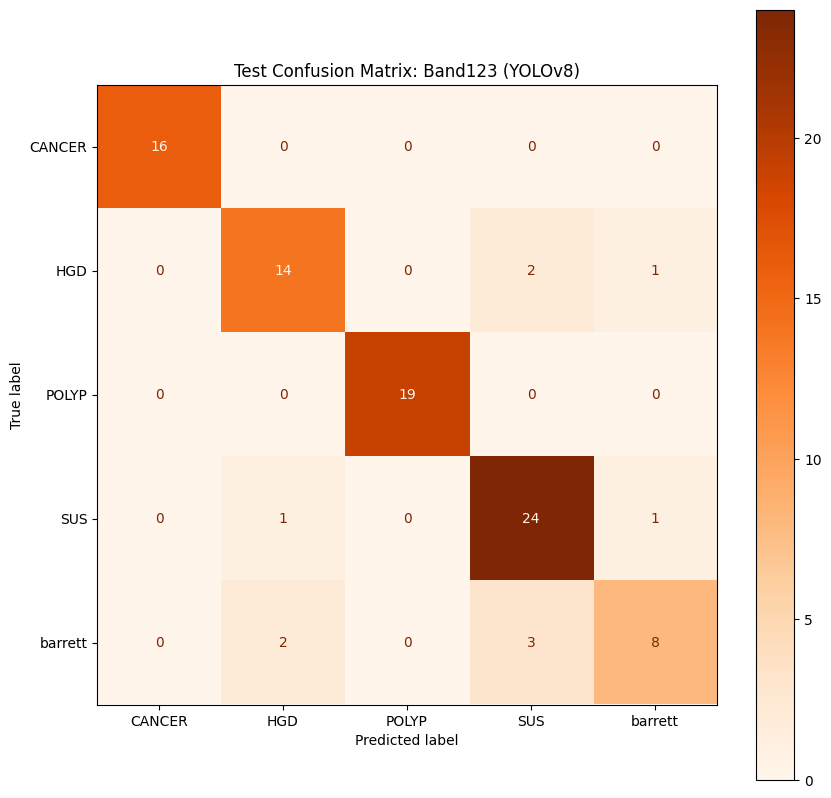

In [ ]:
# ===================== CELL 2: YOLOv8 EXPERIMENT =====================
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from ultralytics import YOLO

# 👇 CHANGE THIS VARIABLE TO SWITCH BANDS
BAND_NAME = "Band123"

# Experiment Config
MODEL_TYPE = "yolov8m-cls.pt"  # Medium model (Balance of speed/accuracy)
MAX_EPOCHS = 30
IMG_SIZE = 224
BATCH_SIZE = 16

# Define Paths
# YOLO is strict about paths. We define the root folder that contains 'train' and 'test'
DATA_ROOT = f'/content/Team 1/{BAND_NAME}'
TRAIN_DIR = f'{DATA_ROOT}/train'
TEST_DIR  = f'{DATA_ROOT}/test'

print(f"🚀 STARTING YOLOv8 EXPERIMENT FOR: {BAND_NAME}")
print(f"📂 Data Root: {DATA_ROOT}")

# ===================== 1. YOLO FOLDER SETUP =====================
# YOLO requires a folder named 'val' to validate during training.
# We will copy your 'test' folder to 'val' so YOLO can use it.
VAL_DIR = f'{DATA_ROOT}/val'

if not os.path.isdir(VAL_DIR):
    print(f"ℹ️ Creating 'val' folder from 'test' for YOLO requirements...")
    # We use copytree to duplicate test data into a val folder
    shutil.copytree(TEST_DIR, VAL_DIR, dirs_exist_ok=True)
    print("✅ 'val' folder created successfully.")
else:
    print("✅ 'val' folder already exists.")

# ===================== 2. TRAINING LOOP =====================
# Load Pretrained Model
model = YOLO(MODEL_TYPE)

print("\n🔄 Phase 1: Training...")
# YOLO handles the training loop internally
results = model.train(
    data=DATA_ROOT,       # Point to folder containing train/val
    epochs=MAX_EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    patience=5,
    project=f"/content/drive/MyDrive/YOLO_Runs",  # Save to Drive
    name=f"{BAND_NAME}_yolo",
    exist_ok=True,        # Overwrite if exists
    verbose=True
)

print(f"✅ Training Complete. Saved to Drive.")

# ===================== 3. FINAL EVALUATION =====================
print(f"\n🔄 Phase 2: Generating Final Classification Report...")

# Load the best model weights from the run we just finished
best_weight_path = f"/content/drive/MyDrive/YOLO_Runs/{BAND_NAME}_yolo/weights/best.pt"
model = YOLO(best_weight_path)

# Get class names from the folder structure
class_names = sorted([d for d in os.listdir(TEST_DIR) if os.path.isdir(os.path.join(TEST_DIR, d))])
class_map = {name: i for i, name in enumerate(class_names)}

y_true = []
y_pred = []

print("⏳ Running inference on Test set...")

# Iterate through each class folder (Like ImageFolder)
for class_name in class_names:
    class_dir = os.path.join(TEST_DIR, class_name)
    image_files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    for img_file in image_files:
        img_path = os.path.join(class_dir, img_file)

        # Run Inference
        result = model(img_path, verbose=False)[0]

        # Store Truth
        y_true.append(class_map[class_name])

        # Store Prediction (Top-1 class index)
        y_pred.append(result.probs.top1)

# ===================== 4. DISPLAY RESULTS =====================
print(f"\n📝 FINAL TEST RESULTS FOR {BAND_NAME} (YOLOv8):")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(10, 10))
disp.plot(cmap="Oranges", values_format='d', ax=plt.gca())
plt.title(f"Test Confusion Matrix: {BAND_NAME} (YOLOv8)")
plt.show()

Band 2 - 90%

🚀 STARTING YOLOv8 EXPERIMENT FOR: Band2
📂 Data Root: /content/Team 1/Band2
ℹ️ Creating 'val' folder from 'test' for YOLO requirements...
✅ 'val' folder created successfully.

🔄 Phase 1: Training...
Ultralytics 8.4.11 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Team 1/Band2, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=t

/usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic 

AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 28.9±3.3 MB/s, size: 63.2 KB)
train: Scanning /content/Team 1/Band2/train... 1095 images, 0 corrupt: 100% ━━━━━━━━━━━━ 1095/1095 535.0it/s 2.0s
train: New cache created: /content/Team 1/Band2/train.cache
val: Fast image access ✅ (ping: 0.2±0.5 ms, read: 634.0±251.7 MB/s, size: 65.4 KB)
val: Scanning /content/Team 1/Band2/val... 91 images, 0 corrupt: 100% ━━━━━━━━━━━━ 91/91 3.6Kit/s 0.0s
val: New cache created: /content/Team 1/Band2/val.cache
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001111, momentum=0.9) with parameter groups 38 weight(decay=0.0), 39 weight(decay=0.0005), 39 bias(decay=0.0)
Image sizes 224 train, 224 val
Using 2 dataloader workers
Logging results to /content/drive/MyDrive/YOLO_Runs/Band2_yolo
Starting training for 30 epochs...

      Epoch    GPU_mem       loss  Instance

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/30      2.92G      1.525          7        224: 100% ━━━━━━━━━━━━ 69/69 5.5it/s 12.5s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 3/3 15.9it/s 0.2s
                   all      0.484          1

      Epoch    GPU_mem       loss  Instances       Size
       2/30      2.97G      1.348         16        224: 1% ──────────── 1/69 1.2it/s 0.3s<56.8s

...

      19/30      4.18G     0.3537          7        224: 100% ━━━━━━━━━━━━ 69/69 6.9it/s 10.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 3/3 33.6it/s 0.1s
                   all      0.857          1

      Epoch    GPU_mem       loss  Instances       Size
      20/30      4.23G     0.3203         16        224: 1% ──────────── 1/69 2.6it/s 0.3s<25.8s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      20/30      4.24G     0.3591          7        224: 100% ━━━━━━━━━━━━ 69/69 5.5it/s 12.6s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 3/3 33.8it/s 0.1s
                   all      0.868          1

      Epoch    GPU_mem       loss  Instances       Size
      21/30      4.32G     0.4704         16        224: 1% ──────────── 1/69 1.9it/s 0.4s<35.1s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      21/30      4.34G     0.3304          7        224: 100% ━━━━━━━━━━━━ 69/69 6.0it/s 11.6s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 3/3 20.7it/s 0.1s
                   all      0.857          1
EarlyStopping: Training stopped early as no improvement observed in last 5 epochs. Best results observed at epoch 16, best model saved as best.pt.
To update EarlyStopping(patience=5) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

21 epochs completed in 0.084 hours.
Optimizer stripped from /content/drive/MyDrive/YOLO_Runs/Band2_yolo/weights/last.pt, 31.7MB
Optimizer stripped from /content/drive/MyDrive/YOLO_Runs/Band2_yolo/weights/best.pt, 31.7MB

Validating /content/drive/MyDrive/YOLO_Runs/Band2_yolo/weights/best.pt...
Ultralytics 8.4.11 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8m-cls summary (fused): 42 layers, 15,769,061 parameters, 0 gradients, 41.6 GFLOPs
train: /content/Team 1/Band2/train..

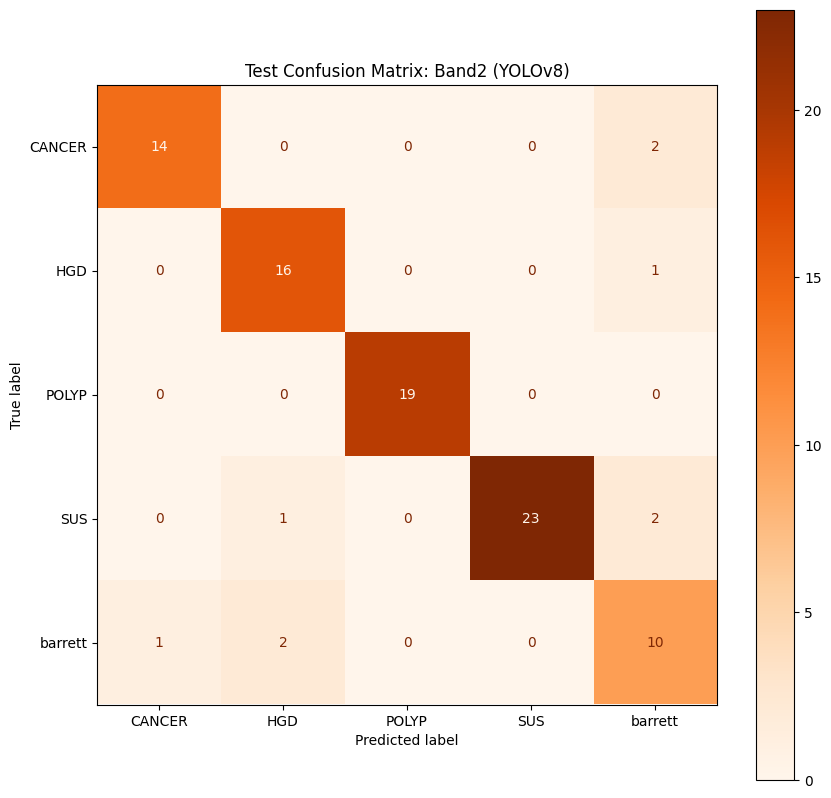

In [ ]:
# ===================== CELL 2: YOLOv8 EXPERIMENT =====================
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from ultralytics import YOLO

# 👇 CHANGE THIS VARIABLE TO SWITCH BANDS
BAND_NAME = "Band2"

# Experiment Config
MODEL_TYPE = "yolov8m-cls.pt"  # Medium model (Balance of speed/accuracy)
MAX_EPOCHS = 30
IMG_SIZE = 224
BATCH_SIZE = 16

# Define Paths
# YOLO is strict about paths. We define the root folder that contains 'train' and 'test'
DATA_ROOT = f'/content/Team 1/{BAND_NAME}'
TRAIN_DIR = f'{DATA_ROOT}/train'
TEST_DIR  = f'{DATA_ROOT}/test'

print(f"🚀 STARTING YOLOv8 EXPERIMENT FOR: {BAND_NAME}")
print(f"📂 Data Root: {DATA_ROOT}")

# ===================== 1. YOLO FOLDER SETUP =====================
# YOLO requires a folder named 'val' to validate during training.
# We will copy your 'test' folder to 'val' so YOLO can use it.
VAL_DIR = f'{DATA_ROOT}/val'

if not os.path.isdir(VAL_DIR):
    print(f"ℹ️ Creating 'val' folder from 'test' for YOLO requirements...")
    # We use copytree to duplicate test data into a val folder
    shutil.copytree(TEST_DIR, VAL_DIR, dirs_exist_ok=True)
    print("✅ 'val' folder created successfully.")
else:
    print("✅ 'val' folder already exists.")

# ===================== 2. TRAINING LOOP =====================
# Load Pretrained Model
model = YOLO(MODEL_TYPE)

print("\n🔄 Phase 1: Training...")
# YOLO handles the training loop internally
results = model.train(
    data=DATA_ROOT,       # Point to folder containing train/val
    epochs=MAX_EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    patience=5,
    project=f"/content/drive/MyDrive/YOLO_Runs",  # Save to Drive
    name=f"{BAND_NAME}_yolo",
    exist_ok=True,        # Overwrite if exists
    verbose=True
)

print(f"✅ Training Complete. Saved to Drive.")

# ===================== 3. FINAL EVALUATION =====================
print(f"\n🔄 Phase 2: Generating Final Classification Report...")

# Load the best model weights from the run we just finished
best_weight_path = f"/content/drive/MyDrive/YOLO_Runs/{BAND_NAME}_yolo/weights/best.pt"
model = YOLO(best_weight_path)

# Get class names from the folder structure
class_names = sorted([d for d in os.listdir(TEST_DIR) if os.path.isdir(os.path.join(TEST_DIR, d))])
class_map = {name: i for i, name in enumerate(class_names)}

y_true = []
y_pred = []

print("⏳ Running inference on Test set...")

# Iterate through each class folder (Like ImageFolder)
for class_name in class_names:
    class_dir = os.path.join(TEST_DIR, class_name)
    image_files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    for img_file in image_files:
        img_path = os.path.join(class_dir, img_file)

        # Run Inference
        result = model(img_path, verbose=False)[0]

        # Store Truth
        y_true.append(class_map[class_name])

        # Store Prediction (Top-1 class index)
        y_pred.append(result.probs.top1)

# ===================== 4. DISPLAY RESULTS =====================
print(f"\n📝 FINAL TEST RESULTS FOR {BAND_NAME} (YOLOv8):")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(10, 10))
disp.plot(cmap="Oranges", values_format='d', ax=plt.gca())
plt.title(f"Test Confusion Matrix: {BAND_NAME} (YOLOv8)")
plt.show()

Band 23 - 88%

🚀 STARTING YOLOv8 EXPERIMENT FOR: Band23
📂 Data Root: /content/Team 1/Band23
ℹ️ Creating 'val' folder from 'test' for YOLO requirements...
✅ 'val' folder created successfully.

🔄 Phase 1: Training...
Ultralytics 8.4.11 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Team 1/Band23, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mod

/usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic 

AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 38.2±16.5 MB/s, size: 82.7 KB)
train: Scanning /content/Team 1/Band23/train... 1095 images, 0 corrupt: 100% ━━━━━━━━━━━━ 1095/1095 555.5it/s 2.0s
train: New cache created: /content/Team 1/Band23/train.cache
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 585.7±271.1 MB/s, size: 82.1 KB)
val: Scanning /content/Team 1/Band23/val... 91 images, 0 corrupt: 100% ━━━━━━━━━━━━ 91/91 2.1Kit/s 0.0s
val: New cache created: /content/Team 1/Band23/val.cache
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001111, momentum=0.9) with parameter groups 38 weight(decay=0.0), 39 weight(decay=0.0005), 39 bias(decay=0.0)
Image sizes 224 train, 224 val
Using 2 dataloader workers
Logging results to /content/drive/MyDrive/YOLO_Runs/Band23_yolo
Starting training for 30 epochs...

      Epoch    GPU_mem       loss  In

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/30      2.75G      1.517          7        224: 100% ━━━━━━━━━━━━ 69/69 4.1it/s 16.7s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 3/3 32.9it/s 0.1s
                   all      0.527          1

      Epoch    GPU_mem       loss  Instances       Size
       2/30      2.79G      1.304         16        224: 1% ──────────── 1/69 1.7it/s 0.2s<40.0s

...

      17/30      3.97G     0.3685          7        224: 100% ━━━━━━━━━━━━ 69/69 5.4it/s 12.7s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 3/3 26.4it/s 0.1s
                   all      0.846          1

      Epoch    GPU_mem       loss  Instances       Size
      18/30      4.06G      0.396         16        224: 3% ──────────── 2/69 3.9it/s 0.3s<17.3s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      18/30      4.08G     0.3629          7        224: 100% ━━━━━━━━━━━━ 69/69 5.9it/s 11.6s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 3/3 22.5it/s 0.1s
                   all      0.846          1

      Epoch    GPU_mem       loss  Instances       Size
      19/30      4.14G     0.3242         16        224: 1% ──────────── 1/69 1.7it/s 0.2s<41.1s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      19/30      4.18G      0.312          7        224: 100% ━━━━━━━━━━━━ 69/69 5.6it/s 12.3s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 3/3 25.9it/s 0.1s
                   all      0.835          1
EarlyStopping: Training stopped early as no improvement observed in last 5 epochs. Best results observed at epoch 14, best model saved as best.pt.
To update EarlyStopping(patience=5) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

19 epochs completed in 0.078 hours.
Optimizer stripped from /content/drive/MyDrive/YOLO_Runs/Band23_yolo/weights/last.pt, 31.7MB
Optimizer stripped from /content/drive/MyDrive/YOLO_Runs/Band23_yolo/weights/best.pt, 31.7MB

Validating /content/drive/MyDrive/YOLO_Runs/Band23_yolo/weights/best.pt...
Ultralytics 8.4.11 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8m-cls summary (fused): 42 layers, 15,769,061 parameters, 0 gradients, 41.6 GFLOPs
train: /content/Team 1/Band23/tra

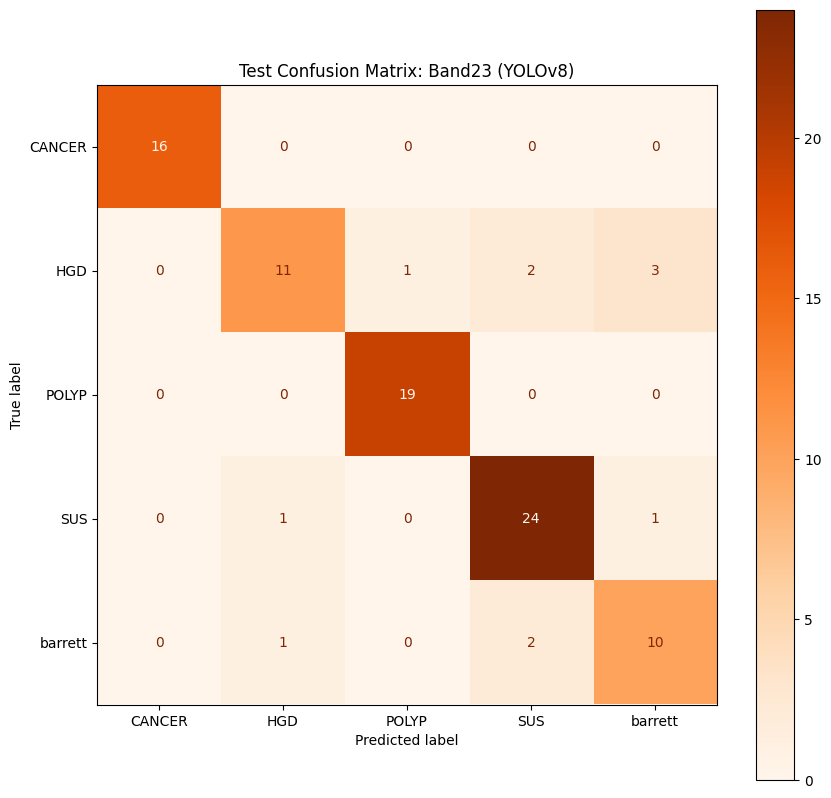

In [ ]:
# ===================== CELL 2: YOLOv8 EXPERIMENT =====================
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from ultralytics import YOLO

# 👇 CHANGE THIS VARIABLE TO SWITCH BANDS
BAND_NAME = "Band23"

# Experiment Config
MODEL_TYPE = "yolov8m-cls.pt"  # Medium model (Balance of speed/accuracy)
MAX_EPOCHS = 30
IMG_SIZE = 224
BATCH_SIZE = 16

# Define Paths
# YOLO is strict about paths. We define the root folder that contains 'train' and 'test'
DATA_ROOT = f'/content/Team 1/{BAND_NAME}'
TRAIN_DIR = f'{DATA_ROOT}/train'
TEST_DIR  = f'{DATA_ROOT}/test'

print(f"🚀 STARTING YOLOv8 EXPERIMENT FOR: {BAND_NAME}")
print(f"📂 Data Root: {DATA_ROOT}")

# ===================== 1. YOLO FOLDER SETUP =====================
# YOLO requires a folder named 'val' to validate during training.
# We will copy your 'test' folder to 'val' so YOLO can use it.
VAL_DIR = f'{DATA_ROOT}/val'

if not os.path.isdir(VAL_DIR):
    print(f"ℹ️ Creating 'val' folder from 'test' for YOLO requirements...")
    # We use copytree to duplicate test data into a val folder
    shutil.copytree(TEST_DIR, VAL_DIR, dirs_exist_ok=True)
    print("✅ 'val' folder created successfully.")
else:
    print("✅ 'val' folder already exists.")

# ===================== 2. TRAINING LOOP =====================
# Load Pretrained Model
model = YOLO(MODEL_TYPE)

print("\n🔄 Phase 1: Training...")
# YOLO handles the training loop internally
results = model.train(
    data=DATA_ROOT,       # Point to folder containing train/val
    epochs=MAX_EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    patience=5,
    project=f"/content/drive/MyDrive/YOLO_Runs",  # Save to Drive
    name=f"{BAND_NAME}_yolo",
    exist_ok=True,        # Overwrite if exists
    verbose=True
)

print(f"✅ Training Complete. Saved to Drive.")

# ===================== 3. FINAL EVALUATION =====================
print(f"\n🔄 Phase 2: Generating Final Classification Report...")

# Load the best model weights from the run we just finished
best_weight_path = f"/content/drive/MyDrive/YOLO_Runs/{BAND_NAME}_yolo/weights/best.pt"
model = YOLO(best_weight_path)

# Get class names from the folder structure
class_names = sorted([d for d in os.listdir(TEST_DIR) if os.path.isdir(os.path.join(TEST_DIR, d))])
class_map = {name: i for i, name in enumerate(class_names)}

y_true = []
y_pred = []

print("⏳ Running inference on Test set...")

# Iterate through each class folder (Like ImageFolder)
for class_name in class_names:
    class_dir = os.path.join(TEST_DIR, class_name)
    image_files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    for img_file in image_files:
        img_path = os.path.join(class_dir, img_file)

        # Run Inference
        result = model(img_path, verbose=False)[0]

        # Store Truth
        y_true.append(class_map[class_name])

        # Store Prediction (Top-1 class index)
        y_pred.append(result.probs.top1)

# ===================== 4. DISPLAY RESULTS =====================
print(f"\n📝 FINAL TEST RESULTS FOR {BAND_NAME} (YOLOv8):")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(10, 10))
disp.plot(cmap="Oranges", values_format='d', ax=plt.gca())
plt.title(f"Test Confusion Matrix: {BAND_NAME} (YOLOv8)")
plt.show()

WLI - 70%

🚀 STARTING YOLOv8 EXPERIMENT FOR: WLI
📂 Data Root: /content/Team 1/WLI
ℹ️ Creating 'val' folder from 'test' for YOLO requirements...
✅ 'val' folder created successfully.

🔄 Phase 1: Training...
Ultralytics 8.4.11 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Team 1/WLI, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, 

/usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic 

AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 34.2±8.6 MB/s, size: 83.6 KB)
train: Scanning /content/Team 1/WLI/train... 1095 images, 0 corrupt: 100% ━━━━━━━━━━━━ 1095/1095 432.8it/s 2.5s
train: New cache created: /content/Team 1/WLI/train.cache
val: Fast image access ✅ (ping: 0.3±0.7 ms, read: 517.1±345.1 MB/s, size: 231.7 KB)
val: Scanning /content/Team 1/WLI/val... 144 images, 0 corrupt: 100% ━━━━━━━━━━━━ 144/144 636.0it/s 0.2s
val: New cache created: /content/Team 1/WLI/val.cache
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001111, momentum=0.9) with parameter groups 38 weight(decay=0.0), 39 weight(decay=0.0005), 39 bias(decay=0.0)
Image sizes 224 train, 224 val
Using 2 dataloader workers
Logging results to /content/drive/MyDrive/YOLO_Runs/WLI_yolo
Starting training for 30 epochs...

      Epoch    GPU_mem       loss  Instances    

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/30      2.72G      1.468          7        224: 100% ━━━━━━━━━━━━ 69/69 5.7it/s 12.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 5/5 17.1it/s 0.3s
                   all      0.569          1

      Epoch    GPU_mem       loss  Instances       Size
       2/30       2.8G      1.122         16        224: 1% ──────────── 1/69 1.5it/s 0.2s<44.5s

...

       6/30      3.07G      0.589          7        224: 100% ━━━━━━━━━━━━ 69/69 5.9it/s 11.7s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 5/5 28.7it/s 0.2s
                   all      0.694          1

      Epoch    GPU_mem       loss  Instances       Size
       7/30      3.16G      0.686         16        224: 1% ──────────── 1/69 1.8it/s 0.3s<38.8s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       7/30      3.16G     0.5363          7        224: 100% ━━━━━━━━━━━━ 69/69 6.4it/s 10.8s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 5/5 25.9it/s 0.2s
                   all      0.681          1

      Epoch    GPU_mem       loss  Instances       Size
       8/30       3.2G     0.5885         16        224: 1% ──────────── 1/69 1.7it/s 0.2s<39.5s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       8/30       3.2G     0.5169          7        224: 100% ━━━━━━━━━━━━ 69/69 6.2it/s 11.2s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 5/5 23.4it/s 0.2s
                   all      0.667          1
EarlyStopping: Training stopped early as no improvement observed in last 5 epochs. Best results observed at epoch 3, best model saved as best.pt.
To update EarlyStopping(patience=5) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

8 epochs completed in 0.031 hours.
Optimizer stripped from /content/drive/MyDrive/YOLO_Runs/WLI_yolo/weights/last.pt, 31.7MB
Optimizer stripped from /content/drive/MyDrive/YOLO_Runs/WLI_yolo/weights/best.pt, 31.7MB

Validating /content/drive/MyDrive/YOLO_Runs/WLI_yolo/weights/best.pt...
Ultralytics 8.4.11 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8m-cls summary (fused): 42 layers, 15,769,061 parameters, 0 gradients, 41.6 GFLOPs
train: /content/Team 1/WLI/train... found 10

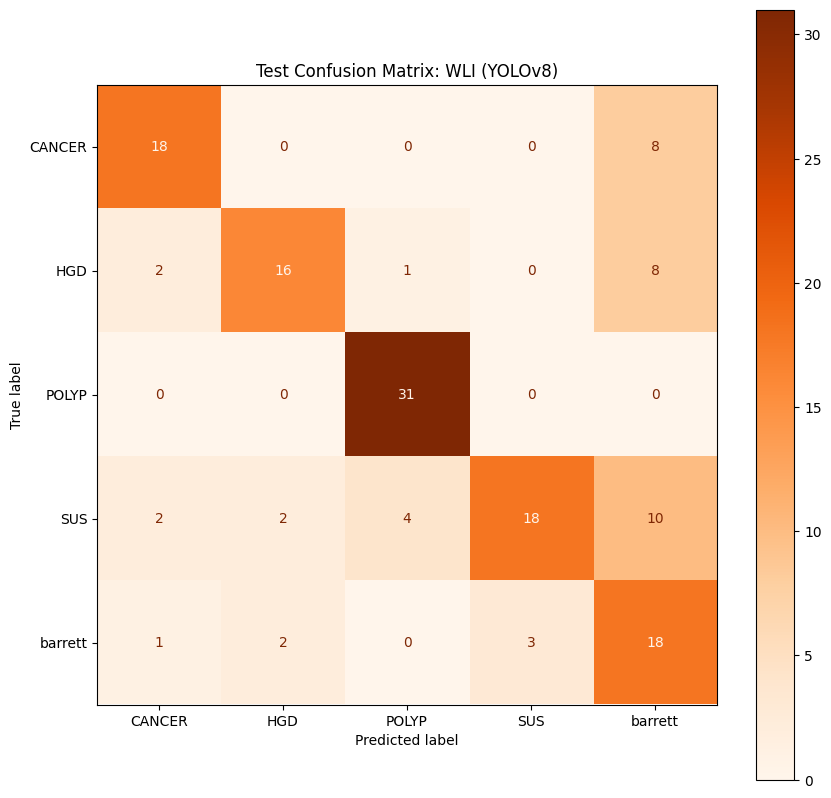

In [ ]:
# ===================== CELL 2: YOLOv8 EXPERIMENT =====================
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from ultralytics import YOLO

# 👇 CHANGE THIS VARIABLE TO SWITCH BANDS
BAND_NAME = "WLI"

# Experiment Config
MODEL_TYPE = "yolov8m-cls.pt"  # Medium model (Balance of speed/accuracy)
MAX_EPOCHS = 30
IMG_SIZE = 224
BATCH_SIZE = 16

# Define Paths
# YOLO is strict about paths. We define the root folder that contains 'train' and 'test'
DATA_ROOT = f'/content/Team 1/{BAND_NAME}'
TRAIN_DIR = f'{DATA_ROOT}/train'
TEST_DIR  = f'{DATA_ROOT}/test'

print(f"🚀 STARTING YOLOv8 EXPERIMENT FOR: {BAND_NAME}")
print(f"📂 Data Root: {DATA_ROOT}")

# ===================== 1. YOLO FOLDER SETUP =====================
# YOLO requires a folder named 'val' to validate during training.
# We will copy your 'test' folder to 'val' so YOLO can use it.
VAL_DIR = f'{DATA_ROOT}/val'

if not os.path.isdir(VAL_DIR):
    print(f"ℹ️ Creating 'val' folder from 'test' for YOLO requirements...")
    # We use copytree to duplicate test data into a val folder
    shutil.copytree(TEST_DIR, VAL_DIR, dirs_exist_ok=True)
    print("✅ 'val' folder created successfully.")
else:
    print("✅ 'val' folder already exists.")

# ===================== 2. TRAINING LOOP =====================
# Load Pretrained Model
model = YOLO(MODEL_TYPE)

print("\n🔄 Phase 1: Training...")
# YOLO handles the training loop internally
results = model.train(
    data=DATA_ROOT,       # Point to folder containing train/val
    epochs=MAX_EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    patience=5,
    project=f"/content/drive/MyDrive/YOLO_Runs",  # Save to Drive
    name=f"{BAND_NAME}_yolo",
    exist_ok=True,        # Overwrite if exists
    verbose=True
)

print(f"✅ Training Complete. Saved to Drive.")

# ===================== 3. FINAL EVALUATION =====================
print(f"\n🔄 Phase 2: Generating Final Classification Report...")

# Load the best model weights from the run we just finished
best_weight_path = f"/content/drive/MyDrive/YOLO_Runs/{BAND_NAME}_yolo/weights/best.pt"
model = YOLO(best_weight_path)

# Get class names from the folder structure
class_names = sorted([d for d in os.listdir(TEST_DIR) if os.path.isdir(os.path.join(TEST_DIR, d))])
class_map = {name: i for i, name in enumerate(class_names)}

y_true = []
y_pred = []

print("⏳ Running inference on Test set...")

# Iterate through each class folder (Like ImageFolder)
for class_name in class_names:
    class_dir = os.path.join(TEST_DIR, class_name)
    image_files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    for img_file in image_files:
        img_path = os.path.join(class_dir, img_file)

        # Run Inference
        result = model(img_path, verbose=False)[0]

        # Store Truth
        y_true.append(class_map[class_name])

        # Store Prediction (Top-1 class index)
        y_pred.append(result.probs.top1)

# ===================== 4. DISPLAY RESULTS =====================
print(f"\n📝 FINAL TEST RESULTS FOR {BAND_NAME} (YOLOv8):")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(10, 10))
disp.plot(cmap="Oranges", values_format='d', ax=plt.gca())
plt.title(f"Test Confusion Matrix: {BAND_NAME} (YOLOv8)")
plt.show()